# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Loading Dataset

In [ ]:
main_df = pd.read_csv("../data/phishing_email_preprocessed.csv")
main_df.head()

,clean_text,label,label_encoded,text_length,word_count,digit_count,uppercase_count,special_char_count,has_url,has_email
0,hpl nom may see attached file hplno xls hplno xls,0,0,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0
1,nom actual vols th forwarded sabrae zajac hou ...,0,0,0.127212,0.019503,-0.014909,-0.00399,-0.177516,0,0
2,enron actuals march april estimated actuals ma...,0,0,-0.933162,-0.251457,-0.014909,-0.00399,-0.177516,0,0
3,hpl nom may see attached file hplno xls hplno xls,0,0,-1.015682,-0.265507,-0.014909,-0.00399,-0.177516,0,0
4,hpl nom june see attached file hplno xls hplno...,0,0,-1.014306,-0.265507,-0.014909,-0.00399,-0.177516,0,0


In [3]:
print("Shape:", main_df.shape)
print("\nColumns:", main_df.columns.tolist())
print("\nInfo:")
print(main_df.info())
print("\nMissing values:")
print(main_df.isnull().sum())

Shape: (82077, 10)

Columns: ['clean_text', 'label', 'label_encoded', 'text_length', 'word_count', 'digit_count', 'uppercase_count', 'special_char_count', 'has_url', 'has_email']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82077 entries, 0 to 82076
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   clean_text          82076 non-null  object 
 1   label               82077 non-null  int64  
 2   label_encoded       82077 non-null  int64  
 3   text_length         82077 non-null  float64
 4   word_count          82077 non-null  float64
 5   digit_count         82077 non-null  float64
 6   uppercase_count     82077 non-null  float64
 7   special_char_count  82077 non-null  float64
 8   has_url             82077 non-null  int64  
 9   has_email           82077 non-null  int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 6.3+ MB
None

Missing values:
clean_text            1
label    

# Dataset Rearranging

In [4]:
# Adjust these names if your dataset uses different column names
TEXT_COL = "clean_text" if "clean_text" in main_df.columns else "text_combined"
LABEL_COL = "label_encoded" if "label_encoded" in main_df.columns else "label"

print("Using text column:", TEXT_COL)
print("Using label column:", LABEL_COL)

Using text column: clean_text
Using label column: label_encoded


In [5]:
if main_df[LABEL_COL].dtype == "object":
    main_df[LABEL_COL] = main_df[LABEL_COL].astype(str).str.strip().str.lower()
    label_map = {
        "phishing": 1,
        "phish": 1,
        "spam": 1,
        "safe": 0,
        "legitimate": 0,
        "ham": 0
    }
    main_df[LABEL_COL] = main_df[LABEL_COL].map(label_map)

main_df = main_df.dropna(subset=[TEXT_COL, LABEL_COL]).copy()
main_df[LABEL_COL] = main_df[LABEL_COL].astype(int)

print(main_df[[TEXT_COL, LABEL_COL]].head())
print(main_df[LABEL_COL].value_counts())

                                          clean_text  label_encoded
0  hpl nom may see attached file hplno xls hplno xls              0
1  nom actual vols th forwarded sabrae zajac hou ...              0
2  enron actuals march april estimated actuals ma...              0
3  hpl nom may see attached file hplno xls hplno xls              0
4  hpl nom june see attached file hplno xls hplno...              0
label_encoded
1    42843
0    39233
Name: count, dtype: int64


# Define X and y

In [6]:
X = main_df[TEXT_COL].astype(str)
y = main_df[LABEL_COL]

# Train test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 65660
Testing samples: 16416


# TF-IDF vectorization

In [8]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

TF-IDF train shape: (65660, 5000)
TF-IDF test shape: (16416, 5000)


# Create a function to evaluate models

In [9]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, dataset_name):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, zero_division=0)
    rec = recall_score(y_te, preds, zero_division=0)
    f1 = f1_score(y_te, preds, zero_division=0)

    print(f"\n===== {model_name} on {dataset_name} =====")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_te, preds, zero_division=0))

    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    }, preds

# Train Logistic Regression

In [10]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_result_main, lr_preds_main = evaluate_model(
    lr_model,
    X_train_tfidf, y_train,
    X_test_tfidf, y_test,
    "Logistic Regression",
    "Primary Dataset"
)


===== Logistic Regression on Primary Dataset =====
Accuracy : 0.9792
Precision: 0.9775
Recall   : 0.9828
F1-score : 0.9802

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



# Train Random Forest

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_result_main, rf_preds_main = evaluate_model(
    rf_model,
    X_train_tfidf, y_train,
    X_test_tfidf, y_test,
    "Random Forest",
    "Primary Dataset"
)


===== Random Forest on Primary Dataset =====
Accuracy : 0.9826
Precision: 0.984
Recall   : 0.9827
F1-score : 0.9834

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.98      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



# Train SVM

In [12]:
svm_model = LinearSVC(random_state=42)

svm_result_main, svm_preds_main = evaluate_model(
    svm_model,
    X_train_tfidf, y_train,
    X_test_tfidf, y_test,
    "SVM",
    "Primary Dataset"
)


===== SVM on Primary Dataset =====
Accuracy : 0.9831
Precision: 0.9815
Recall   : 0.9862
F1-score : 0.9839

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7847
           1       0.98      0.99      0.98      8569

    accuracy                           0.98     16416
   macro avg       0.98      0.98      0.98     16416
weighted avg       0.98      0.98      0.98     16416



# Save primary dataset results

In [13]:
primary_results = pd.DataFrame([
    lr_result_main,
    rf_result_main,
    svm_result_main
])

primary_results

,Model,Dataset,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Primary Dataset,0.979228,0.977484,0.982845,0.980157
1,Random Forest,Primary Dataset,0.982639,0.983992,0.982728,0.983360
2,SVM,Primary Dataset,0.983126,0.981533,0.986229,0.983876


In [ ]:
primary_results.to_csv("../results/week5_primary_results.csv", index=False)

# Confusion Matrix

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [16]:
def plot_and_save_conf_matrix(y_true, y_pred, model_name, dataset_name="Primary Dataset", save_dir="../results/figures"):
    os.makedirs(save_dir, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nConfusion Matrix for {model_name} on {dataset_name}:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name} ({dataset_name})")
    plt.tight_layout()

    file_name = f"{model_name.lower().replace(' ', '_')}_{dataset_name.lower().replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(os.path.join(save_dir, file_name))
    plt.show()

    return cm

In [17]:
def plot_and_save_conf_matrix(y_true, y_pred, model_name, dataset_name="Primary Dataset", save_dir="../results/figures"):
    os.makedirs(save_dir, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred)

    print(f"\nConfusion Matrix for {model_name} on {dataset_name}:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name} ({dataset_name})")
    plt.tight_layout()

    file_name = f"{model_name.lower().replace(' ', '_')}_{dataset_name.lower().replace(' ', '_')}_confusion_matrix.png"
    plt.savefig(os.path.join(save_dir, file_name))
    plt.show()

    return cm


Confusion Matrix for Logistic Regression on Primary Dataset:
[[7653  194]
 [ 147 8422]]


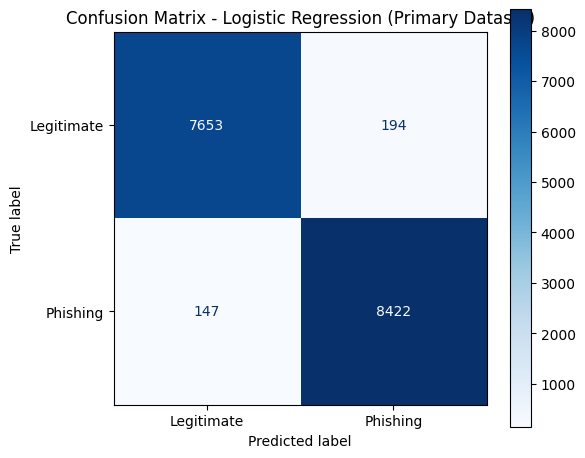

In [18]:
cm_lr = plot_and_save_conf_matrix(
    y_test,
    lr_preds_main,
    "Logistic Regression",
    "Primary Dataset"
)


Confusion Matrix for Random Forest on Primary Dataset:
[[7710  137]
 [ 148 8421]]


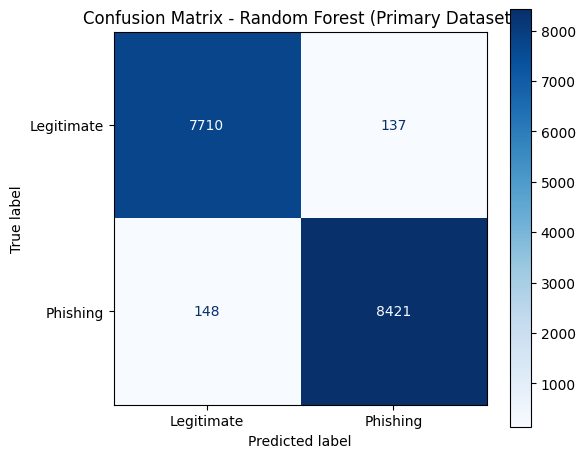

In [19]:
cm_rf = plot_and_save_conf_matrix(
    y_test,
    rf_preds_main,
    "Random Forest",
    "Primary Dataset"
)


Confusion Matrix for SVM on Primary Dataset:
[[7688  159]
 [ 118 8451]]


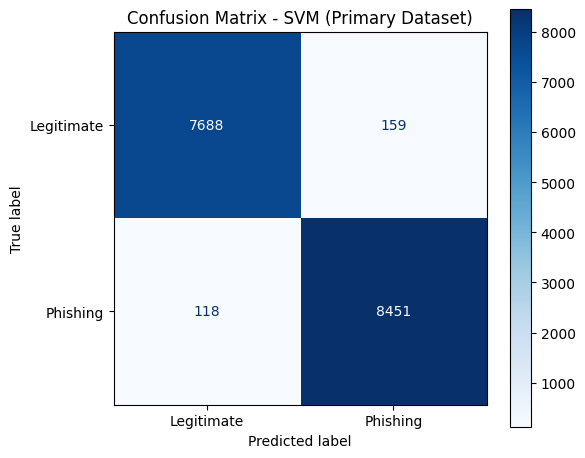

In [20]:
cm_svm = plot_and_save_conf_matrix(
    y_test,
    svm_preds_main,
    "SVM",
    "Primary Dataset"
)

In [21]:
conf_matrix_summary = {
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "TN": [cm_lr[0,0], cm_rf[0,0], cm_svm[0,0]],
    "FP": [cm_lr[0,1], cm_rf[0,1], cm_svm[0,1]],
    "FN": [cm_lr[1,0], cm_rf[1,0], cm_svm[1,0]],
    "TP": [cm_lr[1,1], cm_rf[1,1], cm_svm[1,1]]
}

conf_matrix_df = pd.DataFrame(conf_matrix_summary)
print(conf_matrix_df)

conf_matrix_df.to_csv("../results/week5_confusion_matrices_primary.csv", index=False)

                 Model    TN   FP   FN    TP
0  Logistic Regression  7653  194  147  8422
1        Random Forest  7710  137  148  8421
2                  SVM  7688  159  118  8451


In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# BERT Sample

In [23]:
bert_df = main_df[[TEXT_COL, LABEL_COL]].dropna().copy()

# Use smaller sample if dataset is big
bert_df = bert_df.sample(n=min(3000, len(bert_df)), random_state=42)

train_df, test_df = train_test_split(
    bert_df,
    test_size=0.2,
    random_state=42,
    stratify=bert_df[LABEL_COL]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (2400, 2)
Test shape: (600, 2)


In [24]:
train_df = train_df.rename(columns={TEXT_COL: "text", LABEL_COL: "label"})
test_df = test_df.rename(columns={TEXT_COL: "text", LABEL_COL: "label"})

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

In [25]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [26]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

In [27]:
train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names if col not in ["input_ids", "attention_mask", "label"]]
)
test_dataset = test_dataset.remove_columns(
    [col for col in test_dataset.column_names if col not in ["input_ids", "attention_mask", "label"]]
)

train_dataset.set_format("torch")
test_dataset.set_format("torch")

# Load BERT Model

In [28]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Matrix

In [29]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Training Arguments

In [30]:
import torch, accelerate, transformers
print("torch:", torch.__version__)
print("accelerate:", accelerate.__version__)
print("transformers:", transformers.__version__)

torch: 2.10.0+cu128
accelerate: 1.12.0
transformers: 5.0.0


In [31]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [33]:
training_args = TrainingArguments(
    output_dir="./bert_output",
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    report_to="none",
    use_cpu=True
)

# Train BERT

In [34]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
bert_eval = trainer.evaluate()
bert_eval

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.157120,0.164538,0.953333,0.945687,0.964169,0.954839


{'eval_loss': 0.16453832387924194,
 'eval_accuracy': 0.9533333333333334,
 'eval_precision': 0.9456869009584664,
 'eval_recall': 0.9641693811074918,
 'eval_f1': 0.9548387096774194,
 'eval_runtime': 29.6758,
 'eval_samples_per_second': 20.219,
 'eval_steps_per_second': 2.527,
 'epoch': 1.0}

# BERT Evaluate

In [35]:
bert_result_main = {
    "Model": "BERT",
    "Dataset": "Primary Dataset",
    "Accuracy": bert_eval["eval_accuracy"],
    "Precision": bert_eval["eval_precision"],
    "Recall": bert_eval["eval_recall"],
    "F1-score": bert_eval["eval_f1"]
}

# Comparison

In [36]:
all_results = [
    lr_result_main,
    rf_result_main,
    svm_result_main
]

# add BERT if available
if "bert_result_main" in globals():
    all_results.append(bert_result_main)

final_comparison = pd.DataFrame(all_results)

remarks_map = {
    ("Logistic Regression", "Primary Dataset"): "Strong baseline",
    ("Random Forest", "Primary Dataset"): "Good ensemble model",
    ("SVM", "Primary Dataset"): "Strong text classifier",
    ("BERT", "Primary Dataset"): "Advanced contextual NLP"
}

final_comparison["Remarks"] = final_comparison.apply(
    lambda row: remarks_map.get((row["Model"], row["Dataset"]), ""),
    axis=1
)

final_comparison

,Model,Dataset,Accuracy,Precision,Recall,F1-score,Remarks
0,Logistic Regression,Primary Dataset,0.979228,0.977484,0.982845,0.980157,Strong baseline
1,Random Forest,Primary Dataset,0.982639,0.983992,0.982728,0.983360,Good ensemble model
2,SVM,Primary Dataset,0.983126,0.981533,0.986229,0.983876,Strong text classifier
3,BERT,Primary Dataset,0.953333,0.945687,0.964169,0.954839,Advanced contextual NLP


In [ ]:
final_comparison.to_csv("../results/week5_final_comparison.csv", index=False)

# Accuracy Comparison

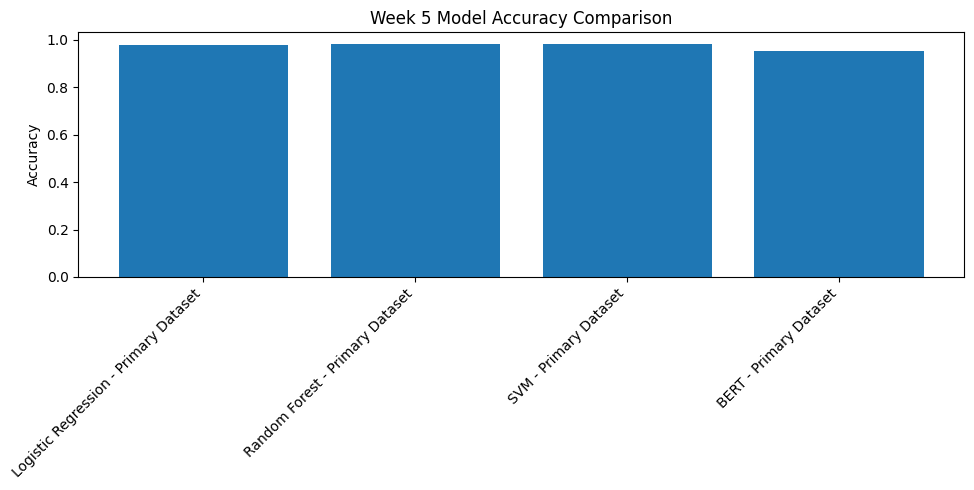

In [38]:
plt.figure(figsize=(10, 5))
plt.bar(final_comparison["Model"] + " - " + final_comparison["Dataset"], final_comparison["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Week 5 Model Accuracy Comparison")
plt.tight_layout()
plt.show()

# F1 Chart Comparison

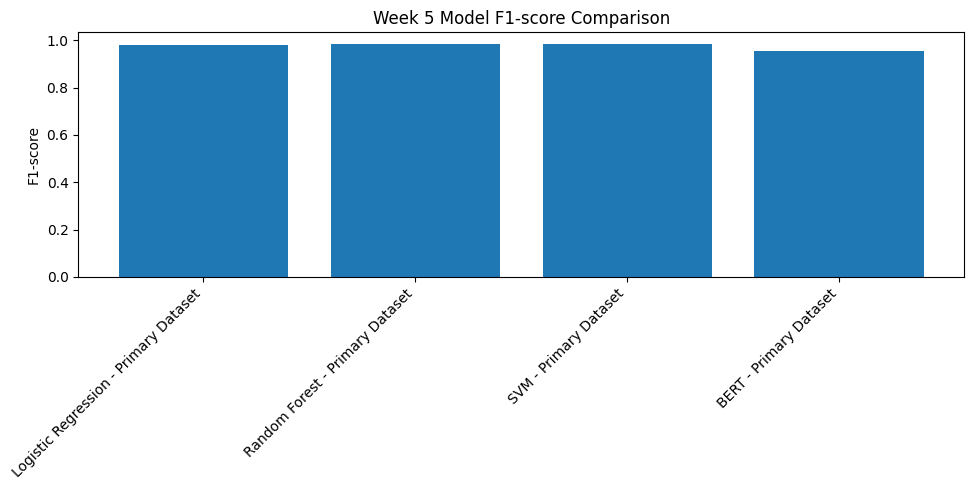

In [39]:
plt.figure(figsize=(10, 5))
plt.bar(final_comparison["Model"] + " - " + final_comparison["Dataset"], final_comparison["F1-score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Week 5 Model F1-score Comparison")
plt.tight_layout()
plt.show()

# Save figures

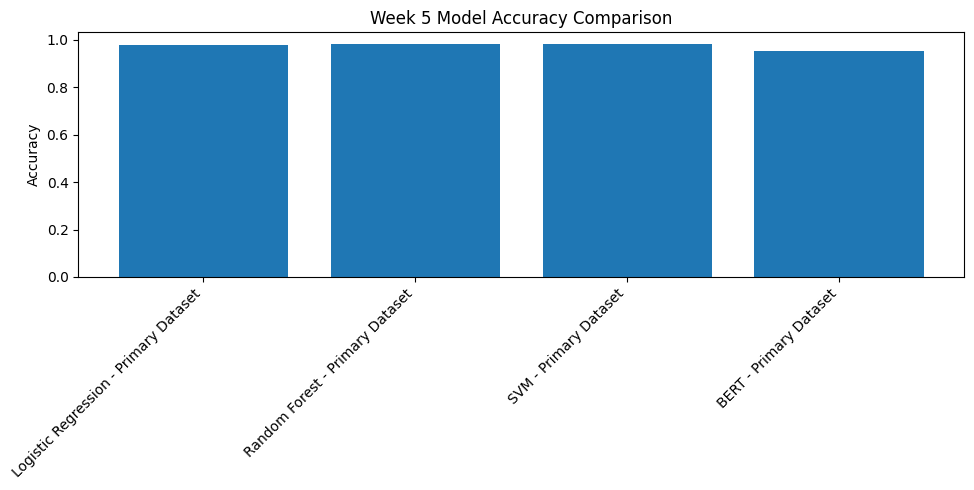

In [ ]:
os.makedirs("../results/figures", exist_ok=True)

plt.figure(figsize=(10, 5))
plt.bar(final_comparison["Model"] + " - " + final_comparison["Dataset"], final_comparison["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Week 5 Model Accuracy Comparison")
plt.tight_layout()
plt.savefig("../results/figures/week5_accuracy_comparison.png")
plt.show()

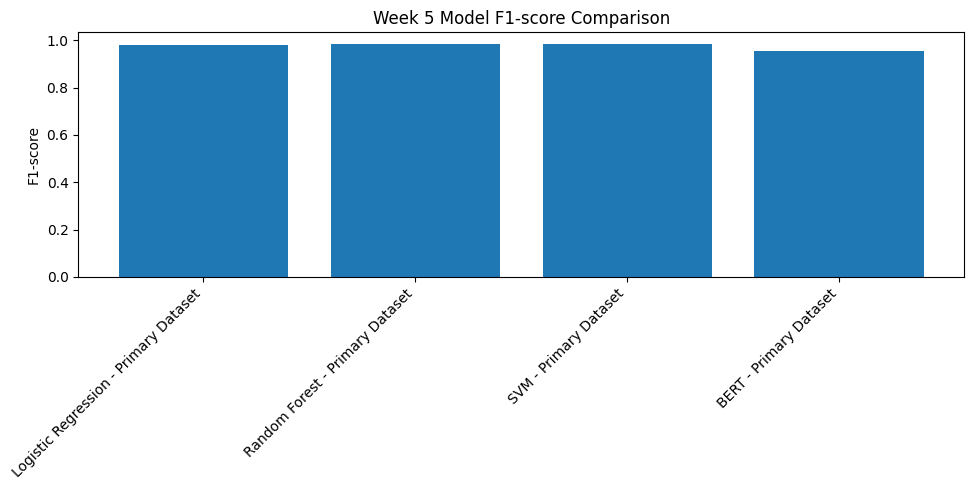

In [ ]:


plt.figure(figsize=(10, 5))
plt.bar(final_comparison["Model"] + " - " + final_comparison["Dataset"], final_comparison["F1-score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Week 5 Model F1-score Comparison")
plt.tight_layout()
plt.savefig("../results/figures/week5_f1score_comparison.png")
plt.show()